# Esqueletização com Poda Baseada em Distância (EDT) e B-splines
### Pipeline Híbrido: Zhang-Suen (1984) + Poda por Distância Euclidiana + B-splines

> 💡 **Nota Metodológica & Esclarecimento Teórico:**
> Este notebook implementa o modelo de referência de medição morfológica de plântulas. Embora o arquivo tenha sido inicialmente intitulado com a sigla *"MAT com Poda"*, a extração 2D do esqueleto é realizada pela função `skimage.morphology.skeletonize`, que por padrão executa rigorosamente o algoritmo de afinamento paralelo de **Zhang-Suen (1984)**. O componente que faz alusão ao conceito de MAT (*Medial Axis*) reside na aplicação da **Transformada de Distância Euclidiana (EDT - `distance_transform_edt`)**, empregada para quantificar a espessura local, podar espículas espúrias (`prune_skeleton_by_dt`) e orientar o ajuste das **B-splines cúbicas**.
> Para a implementação da Transformada do Eixo Medial pura de Harry Blum (1967) calculada via cristas do campo de distâncias, consulte o notebook [`Esqueletizacao_MAT_Puro.ipynb`](Esqueletizacao_MAT_Puro.ipynb).


In [1]:
import os
import glob
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.ndimage import distance_transform_edt, binary_fill_holes
from skimage.morphology import skeletonize
from scipy.interpolate import splprep, splev

In [3]:
# ============================================================
# CÉLULA 2 — Caminhos dos Dados
# ============================================================
import os
import glob
from pathlib import Path

# Diretório base do projeto
BASE_DIR = Path(".").resolve()

# Função para localizar diretórios locais (suporta a estrutura padrão e pastas renomeadas)
def find_dir(*candidates):
    for c in candidates:
        if os.path.isdir(c):
            return c
        p = BASE_DIR / c
        if p.is_dir():
            return str(p)
    return candidates[0]

# Caminhos locais das pastas do projeto
IMGS_PATH  = find_dir("originals-dataset", "originals")
MASKS_PATH = find_dir("labeled-dataset", "labeled")

# Extensões comuns
EXTS = ("*.png", "*.jpg", "*.jpeg", "*.tif", "*.tiff", "*.bmp")

def list_files(folder, exts=EXTS):
    files = []
    for e in exts:
        files.extend(glob.glob(os.path.join(folder, e)))
    return sorted(files)

img_files  = list_files(IMGS_PATH)
mask_files = list_files(MASKS_PATH)

print(f"Caminho das imagens originais: {IMGS_PATH}")
print(f"Encontradas {len(img_files)} imagens originais")
print(f"\nCaminho das máscaras anotadas: {MASKS_PATH}")
print(f"Encontradas {len(mask_files)} máscaras")
print("Exemplos:", mask_files[:3])


Caminho das imagens originais: originals-dataset
Encontradas 170 imagens originais

Caminho das máscaras anotadas: labeled-dataset
Encontradas 170 máscaras
Exemplos: ['labeled-dataset/C10-R10_jpg.rf.2b60af9ef91cf8b6498373f3b6e37f9b.png', 'labeled-dataset/C10-R1_jpg.rf.af80aabb40f12f0cf4bdbea27dc18f1e.png', 'labeled-dataset/C10-R2_jpg.rf.d0d8d58a5a0f1276f9792694c4ca3db7.png']


In [4]:
# ============================================================
# CÉLULA 3 — Descobrir o formato das máscaras
# ============================================================
def inspect_mask(mask_path):
    """Inspeciona uma máscara para descobrir formato e valores únicos."""
    m = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)
    print(f"Arquivo: {os.path.basename(mask_path)}")
    print(f"  Shape: {m.shape}")
    print(f"  Dtype: {m.dtype}")
    if m.ndim == 3:
        print(f"  Canais: {m.shape[2]}")
        # Amostrar cores únicas
        pixels = m.reshape(-1, m.shape[2])
        unique_colors = np.unique(pixels, axis=0)
        print(f"  Cores únicas: {len(unique_colors)}")
        print(f"  Primeiras 10 cores: \n{unique_colors[:10]}")
    else:
        unique_vals = np.unique(m)
        print(f"  Valores únicos: {unique_vals[:20]}")

inspect_mask(mask_files[0])

Arquivo: C10-R10_jpg.rf.2b60af9ef91cf8b6498373f3b6e37f9b.png
  Shape: (640, 640, 3)
  Dtype: uint8
  Canais: 3
  Cores únicas: 4
  Primeiras 10 cores: 
[[  0   0   0]
 [  5  10 245]
 [ 15 250  20]
 [255  25  30]]


In [5]:
# ============================================================
# CÉLULA 4 (CORRIGIDA) — Extração por cor exata
# ============================================================
COLOR_HYP  = np.array([15, 250, 20])   # verde
COLOR_ROOT = np.array([5, 10, 245])    # vermelho
COLOR_COT  = np.array([255, 25, 30])   # azul

def extract_organ_masks(mask, tol=10):
    if mask.ndim != 3 or mask.shape[2] != 3:
        raise ValueError("Esperando máscara RGB/BGR de 3 canais")
    m = mask.astype(int)
    def color_match(color):
        return np.all(np.abs(m - color) <= tol, axis=-1)
    return color_match(COLOR_HYP), color_match(COLOR_ROOT), color_match(COLOR_COT)

# Teste
test_mask = cv2.imread(mask_files[0], cv2.IMREAD_UNCHANGED)
mask_hyp, mask_root, mask_cot = extract_organ_masks(test_mask)

print(f"Hipocótilo: {mask_hyp.sum():>8} pixels")
print(f"Raiz:       {mask_root.sum():>8} pixels")
print(f"Cotilédone: {mask_cot.sum():>8} pixels")
print(f"Total de pixels coloridos: "
      f"{(mask_hyp | mask_root | mask_cot).sum()}")

Hipocótilo:     7429 pixels
Raiz:          12890 pixels
Cotilédone:    22246 pixels
Total de pixels coloridos: 42565


In [6]:
# ============================================================
# CÉLULA 5 (CORRIGIDA) — Pipeline sem MORPH_OPEN
# ============================================================
from scipy.ndimage import distance_transform_edt, binary_fill_holes, label
from skimage.morphology import skeletonize
from scipy.interpolate import splprep, splev

def preprocess_mask(mask):
    binary = mask.astype(bool)
    binary = binary_fill_holes(binary)
    kernel = np.ones((3, 3), np.uint8)
    b_u8 = (binary * 255).astype(np.uint8)
    b_u8 = cv2.morphologyEx(b_u8, cv2.MORPH_CLOSE, kernel)
    return b_u8 > 0

def filter_small_components(mask, min_size=30):
    labeled, n = label(mask)
    if n == 0:
        return mask
    sizes = np.bincount(labeled.ravel())
    sizes[0] = 0
    keep = np.where(sizes >= min_size)[0]
    return np.isin(labeled, keep)


def compute_skeleton_chain(skeleton, dist):
    """
    Ordena o esqueleto em cadeia. Se houver múltiplos componentes
    (várias plântulas na mesma máscara), retorna uma lista de cadeias.
    """
    coords = set(map(tuple, np.argwhere(skeleton)))
    if not coords:
        return []

    def neighbors(p):
        y, x = p
        for dy in (-1, 0, 1):
            for dx in (-1, 0, 1):
                if dy == 0 and dx == 0:
                    continue
                q = (y + dy, x + dx)
                if q in coords:
                    yield q

    # Separar em componentes conectados
    visited_global = set()
    chains = []

    for seed in coords:
        if seed in visited_global:
            continue
        # BFS para achar o componente
        component = set()
        stack = [seed]
        while stack:
            p = stack.pop()
            if p in component:
                continue
            component.add(p)
            for q in neighbors(p):
                if q not in component:
                    stack.append(q)
        visited_global |= component

        # Encontrar extremidades do componente
        sub = component
        def nbrs_sub(p):
            y, x = p
            for dy in (-1, 0, 1):
                for dx in (-1, 0, 1):
                    if dy == 0 and dx == 0:
                        continue
                    q = (y + dy, x + dx)
                    if q in sub:
                        yield q

        endpoints = [p for p in sub if sum(1 for _ in nbrs_sub(p)) == 1]
        if not endpoints:
            endpoints = [next(iter(sub))]

        # Escolher o endpoint mais distante do centroide
        centroid = np.mean(list(sub), axis=0)
        start = max(endpoints, key=lambda p: np.linalg.norm(np.array(p) - centroid))

        # Percorrer em cadeia
        visited = {start}
        chain = [start]
        current = start
        while True:
            next_pixels = [q for q in nbrs_sub(current) if q not in visited]
            if not next_pixels:
                break
            # Em bifurcação, seguir o vizinho com maior DT (eixo principal)
            nxt = max(next_pixels, key=lambda q: dist[q])
            visited.add(nxt)
            chain.append(nxt)
            current = nxt

        if len(chain) >= 2:
            chains.append(chain)

    return chains


def prune_skeleton_by_dt(skeleton, dist, min_length=5, min_dt_ratio=0.5):
    skel = skeleton.copy()
    max_dt = dist[skel].max() if skel.any() else 1.0

    changed = True
    while changed:
        changed = False
        coords = set(map(tuple, np.argwhere(skel)))

        def neighbors(p):
            y, x = p
            for dy in (-1, 0, 1):
                for dx in (-1, 0, 1):
                    if dy == 0 and dx == 0:
                        continue
                    q = (y + dy, x + dx)
                    if q in coords:
                        yield q

        endpoints = [p for p in coords if sum(1 for _ in neighbors(p)) == 1]

        for ep in endpoints:
            branch = [ep]
            visited = {ep}
            current = ep
            while True:
                nbrs = [q for q in neighbors(current) if q not in visited]
                if len(nbrs) != 1:
                    break
                current = nbrs[0]
                visited.add(current)
                deg = sum(1 for _ in neighbors(current))
                branch.append(current)
                if deg > 2:
                    break

            if len(branch) < min_length:
                dt_values = [dist[p] for p in branch]
                if np.mean(dt_values) < min_dt_ratio * max_dt:
                    for p in branch:
                        skel[p] = False
                    changed = True

    return skel


def chain_length_pixels(chain):
    length = 0.0
    for i in range(1, len(chain)):
        dy = chain[i][0] - chain[i-1][0]
        dx = chain[i][1] - chain[i-1][1]
        length += np.hypot(dy, dx)
    return length


def chain_length_spline(chain, n_points=500):
    if len(chain) < 4:
        return chain_length_pixels(chain)
    pts = np.array(chain)
    try:
        tck, _ = splprep([pts[:, 0], pts[:, 1]], s=0, k=3)
        u = np.linspace(0, 1, n_points)
        y_s, x_s = splev(u, tck)
        diffs = np.diff(np.column_stack([y_s, x_s]), axis=0)
        return np.sum(np.hypot(diffs[:, 0], diffs[:, 1]))
    except Exception:
        return chain_length_pixels(chain)


def measure_organ(mask, pixels_per_cm, use_spline=True,
                  min_branch_length=5, min_dt_ratio=0.5,
                  min_component_size=30):
    binary = preprocess_mask(mask)
    binary = filter_small_components(binary, min_size=min_component_size)

    dist = distance_transform_edt(binary)
    skeleton = skeletonize(binary)
    skeleton_pruned = prune_skeleton_by_dt(
        skeleton, dist,
        min_length=min_branch_length,
        min_dt_ratio=min_dt_ratio
    )
    chains = compute_skeleton_chain(skeleton_pruned, dist)

    lengths_px = []
    for chain in chains:
        if len(chain) < 2:
            continue
        L = chain_length_spline(chain) if use_spline else chain_length_pixels(chain)
        lengths_px.append(L)

    lengths_cm = [L / pixels_per_cm for L in lengths_px]

    return {
        "lengths_px": lengths_px,
        "lengths_cm": lengths_cm,
        "n_organs": len(lengths_px),
        "dist": dist,
        "skeleton": skeleton_pruned,
        "chains": chains,
        "binary_clean": binary,
    }


In [7]:
# ============================================================
# CÉLULA 6 — Calibração pixels/cm
# ============================================================
# Você precisa medir quantos pixels equivalem a 1 cm na sua imagem.
# Se as imagens têm 640x640 e você sabe a escala real, insira aqui.
# Exemplo: se 1 cm = 100 pixels, então:
PIXELS_PER_CM = 100.0   # AJUSTE CONFORME SUA IMAGEM

# Se houver uma régua na imagem, você pode detectá-la manualmente
# abrindo uma imagem localmente e medindo.
# Por enquanto, use um valor provisório.


Máscara: C10-R10_jpg.rf.2b60af9ef91cf8b6498373f3b6e37f9b.png
  Hipocótilo: 49 órgãos
  Raiz:       48 órgãos


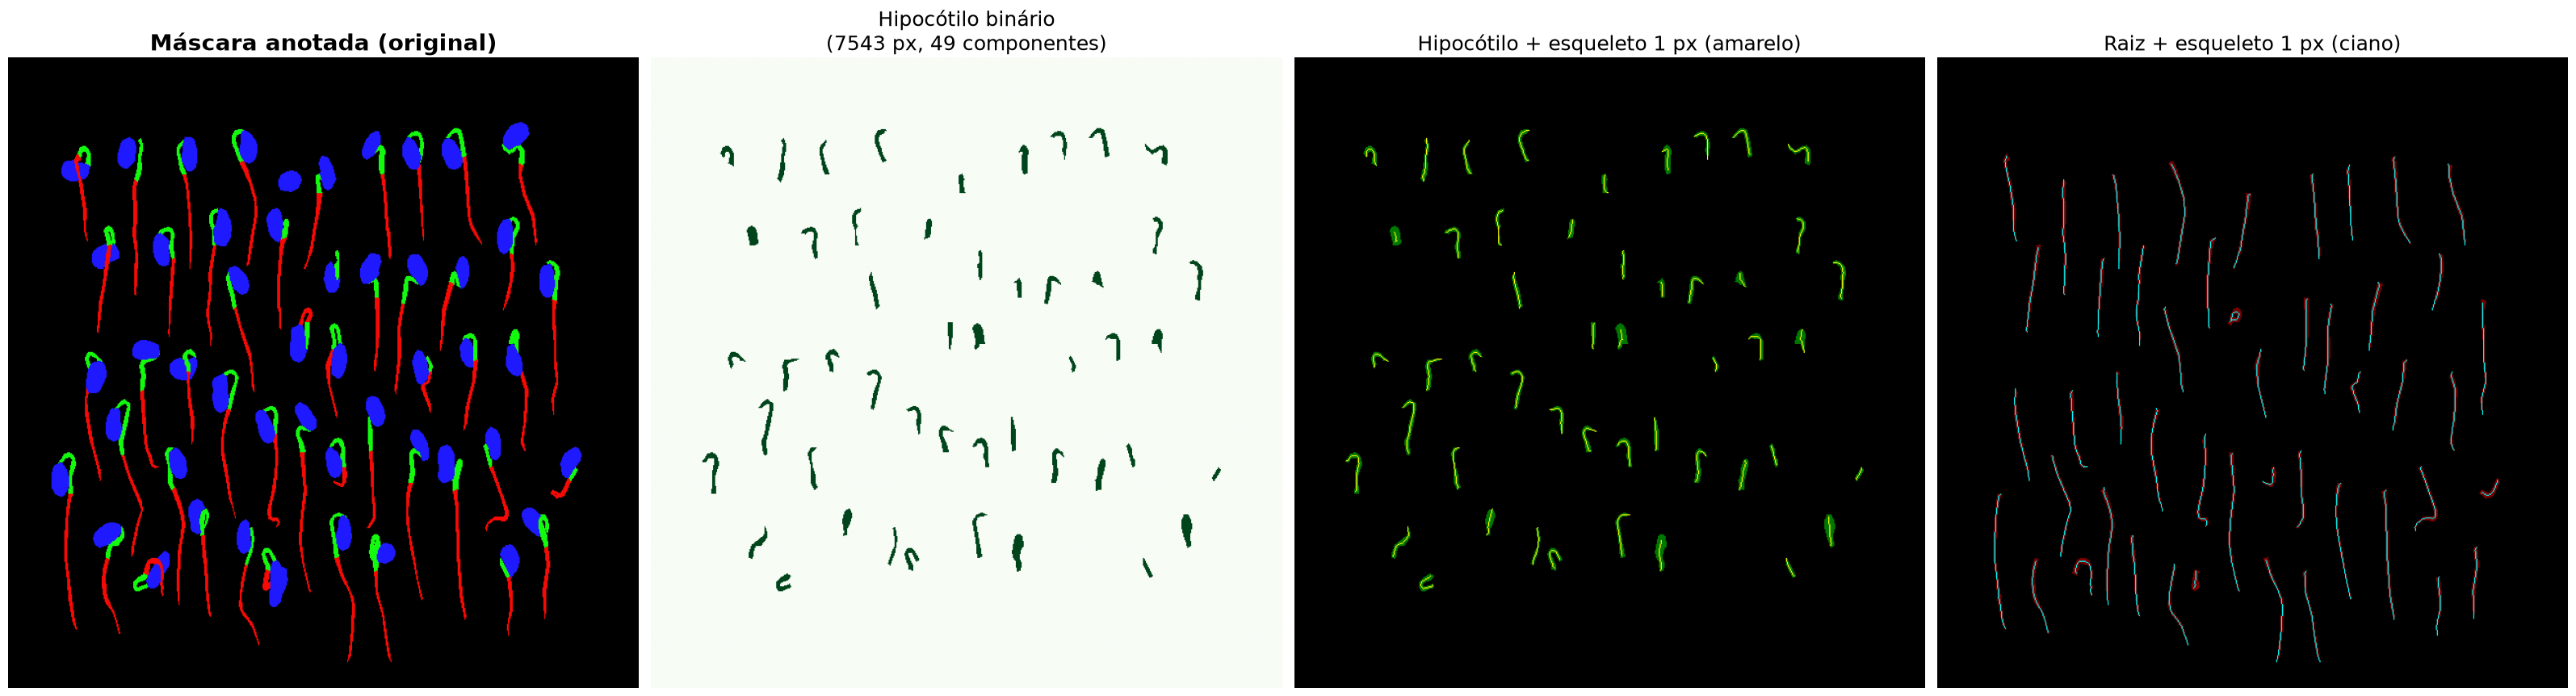

In [8]:
# ============================================================
# CÉLULA 7 (CORRIGIDA) — Testar e visualizar com esqueleto de 1 px
# ============================================================
import matplotlib.pyplot as plt

test_path = mask_files[0]
test_mask = cv2.imread(test_path, cv2.IMREAD_UNCHANGED)
mask_hyp, mask_root, mask_cot = extract_organ_masks(test_mask)

# Aplicar pré-processamento e filtro para ver a máscara limpa
mask_hyp_clean  = filter_small_components(preprocess_mask(mask_hyp),  30)
mask_root_clean = filter_small_components(preprocess_mask(mask_root), 30)

result_hyp  = measure_organ(mask_hyp,  PIXELS_PER_CM)
result_root = measure_organ(mask_root, PIXELS_PER_CM)

print(f"Máscara: {os.path.basename(test_path)}")
print(f"  Hipocótilo: {result_hyp['n_organs']} órgãos")
print(f"  Raiz:       {result_root['n_organs']} órgãos")

# Visualização em 4 painéis grandes
fig, axes = plt.subplots(1, 4, figsize=(32, 10))

# Painel 1: máscara anotada original
axes[0].imshow(cv2.cvtColor(test_mask, cv2.COLOR_BGR2RGB))
axes[0].set_title("Máscara anotada (original)", fontsize=20, fontweight='bold')

# Painel 2: hipocótilo binário limpo
axes[1].imshow(mask_hyp_clean, cmap='Greens')
axes[1].set_title(f"Hipocótilo binário\n"
                  f"({mask_hyp_clean.sum()} px, {result_hyp['n_organs']} componentes)",
                  fontsize=18)

# Painel 3: hipocótilo com esqueleto de 1 px
vis_hyp = np.zeros((*mask_hyp_clean.shape, 3), dtype=np.uint8)
vis_hyp[mask_hyp_clean] = (0, 120, 0)
for chain in result_hyp["chains"]:
    for y, x in chain:
        vis_hyp[y, x] = (255, 255, 0)   # ← ALTERADO: 1 pixel real
axes[2].imshow(vis_hyp)
axes[2].set_title("Hipocótilo + esqueleto 1 px (amarelo)", fontsize=18)

# Painel 4: raiz com esqueleto de 1 px
vis_root = np.zeros((*mask_root_clean.shape, 3), dtype=np.uint8)
vis_root[mask_root_clean] = (120, 0, 0)
for chain in result_root["chains"]:
    for y, x in chain:
        vis_root[y, x] = (0, 255, 255)  # ← ALTERADO: 1 pixel real
axes[3].imshow(vis_root)
axes[3].set_title("Raiz + esqueleto 1 px (ciano)", fontsize=18)

for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()